# 02 · Quem paga quem, e como: pessoas, empresas, chave e QR Code

**Perguntas deste notebook**
- **(Pergunta 3)** Quanto do Pix é pessoa pagando pessoa, e quanto é pessoa pagando **empresa**? O Pix está substituindo cartão e boleto no comércio?
- **(Pergunta 5)** Como o Pix é feito: **chave**, **QR Code** ou **digitando agência e conta**? O QR Code está ganhando espaço?
- **Hipótese do notebook 01:** o ticket médio voltou a subir porque as **empresas** passaram a usar mais o Pix. Vamos testar.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import estilo, categorias as cat
from estilo import br

estilo.aplicar()
pd.set_option("display.float_format", lambda v: br(v, 1))

df = pd.read_parquet(RAIZ / "data/raw/estatisticas.parquet",
                     columns=["AnoMes", "NATUREZA", "FORMAINICIACAO", "VALOR", "QUANTIDADE"])

## 1. Traduzindo os códigos

Os códigos do Banco Central (`P2B`, `QRDN`…) são ótimos para máquina e péssimos para gráfico. Em `src/categorias.py` criamos um **"de-para"**, um dicionário que traduz cada código para um nome legível e agrupa os casos raros:
- `NATUREZA`: tudo que envolve governo (`P2G`, `G2P`, `B2G`…) vira **"Governo (qualquer ponta)"**, porque é menos de 1% das transações;
- `FORMAINICIACAO`: modalidades novas e pequenas (Pix Automático, iniciadores) viram **"Outras"**.

Deixar essas regras num arquivo separado é uma boa prática: o dashboard vai usar **exatamente as mesmas**, então os números nunca divergem.

In [2]:
df["natureza"] = cat.natureza(df["NATUREZA"])
df["forma"] = cat.forma(df["FORMAINICIACAO"])
df["mes"] = cat.para_data(df["AnoMes"])

# conferindo o de-para: quanto de cada categoria no total do período
df.groupby("natureza", dropna=False)["QUANTIDADE"].sum().sort_values(ascending=False) / 1e9

natureza
Pessoa → Pessoa            121,7
Pessoa → Empresa            94,7
Empresa → Pessoa            21,2
Empresa → Empresa            8,3
Governo (qualquer ponta)     0,9
NaN                          0,0
Name: QUANTIDADE, dtype: float64

## 2. Pergunta 3: quem paga quem?

### 2.1 Participação na quantidade de Pix

Para cada mês calculamos a **participação (%)** de cada tipo na quantidade total. O `pivot_table` transforma a tabela "longa" (uma linha por grupo) em "larga" (uma coluna por natureza), igual a uma **tabela dinâmica do Excel**.

In [3]:
qtd = df.pivot_table(index="mes", columns="natureza", values="QUANTIDADE", aggfunc="sum")[cat.NATUREZA_ORDEM]
part_qtd = qtd.div(qtd.sum(axis=1), axis=0) * 100   # cada linha passa a somar 100%
part_qtd.tail(3)

natureza,Pessoa → Pessoa,Pessoa → Empresa,Empresa → Pessoa,Empresa → Empresa,Governo (qualquer ponta)
mes,,,,,
2026-06-01,"39,8","46,0","9,6","4,1","0,5"
2026-07-01,"39,5","46,4","9,4","4,2","0,5"
2026-08-01,"39,5","46,6","9,3","4,2","0,4"


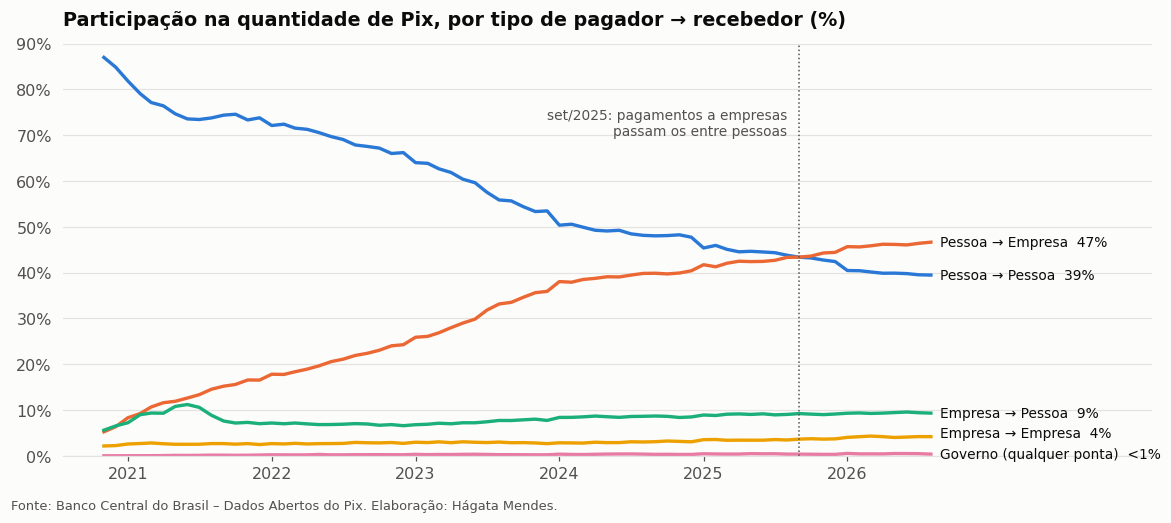

In [4]:
cores = dict(zip(cat.NATUREZA_ORDEM, estilo.CATEGORICAS))

fig, ax = plt.subplots(figsize=(11, 4.6))
for nome in cat.NATUREZA_ORDEM:
    s = part_qtd[nome]
    ax.plot(s.index, s, color=cores[nome])

cruz = part_qtd.index[part_qtd["Pessoa → Empresa"] > part_qtd["Pessoa → Pessoa"]].min()
ax.axvline(cruz, color=estilo.TEXTO_2, lw=1, ls=":")
ax.annotate(f"{estilo.mes_abrev(cruz)}/{cruz.year}: pagamentos a empresas\npassam os entre pessoas",
            (cruz, 70), xytext=(-8, 0), textcoords="offset points", ha="right", fontsize=9, color=estilo.TEXTO_2)
ax.set_title("Participação na quantidade de Pix, por tipo de pagador → recebedor (%)")
ax.set_ylim(0, 90)
estilo.rotulos_finais(ax, {f"{n}  {estilo.pct(part_qtd[n].iloc[-1])}": part_qtd[n] for n in cat.NATUREZA_ORDEM})
ax.set_xlim(right=part_qtd.index[-1] + pd.Timedelta(days=560))
ax.set_xticks([pd.Timestamp(a, 1, 1) for a in range(part_qtd.index[0].year + 1, part_qtd.index[-1].year + 1)], [str(a) for a in range(part_qtd.index[0].year + 1, part_qtd.index[-1].year + 1)])
estilo.eixo_br(ax, 0, "%")
estilo.fonte(fig)
plt.tight_layout(); plt.show()

**Leitura:** no lançamento, **87%** dos Pix eram entre pessoas, o "manda um Pix aí". Hoje são **39%**. Quem cresceu foi **pessoa → empresa**, de **5%** para **47%**, que **ultrapassou** o Pix entre pessoas em **set/2025**.

👉 Resposta à pergunta 3: **sim, o Pix virou meio de pagamento no comércio.** Hoje, a transação de Pix mais comum é alguém pagando uma empresa.

### 2.2 Quantidade conta uma história, valor conta outra

Agora comparamos, no acumulado de 2026 (jan–ago), a participação de cada tipo na **quantidade** e no **valor**.

In [5]:
ultimo = df["AnoMes"].max()
ano_atual = df[(df["AnoMes"] // 100 == ultimo // 100)]
tot = ano_atual.groupby("natureza")[["QUANTIDADE", "VALOR"]].sum().reindex(cat.NATUREZA_ORDEM)
comp = pd.DataFrame({
    "% da quantidade": tot["QUANTIDADE"] / tot["QUANTIDADE"].sum() * 100,
    "% do valor": tot["VALOR"] / tot["VALOR"].sum() * 100,
    "ticket médio (R$)": tot["VALOR"] / tot["QUANTIDADE"],
})
comp

,% da quantidade,% do valor,ticket médio (R$)
natureza,,,
Pessoa → Pessoa,"39,9","24,8","268,5"
Pessoa → Empresa,"46,1","11,7","109,8"
Empresa → Pessoa,"9,4","11,5","528,9"
Empresa → Empresa,"4,2","50,5","5.259,6"
Governo (qualquer ponta),"0,5","1,6","1.468,2"


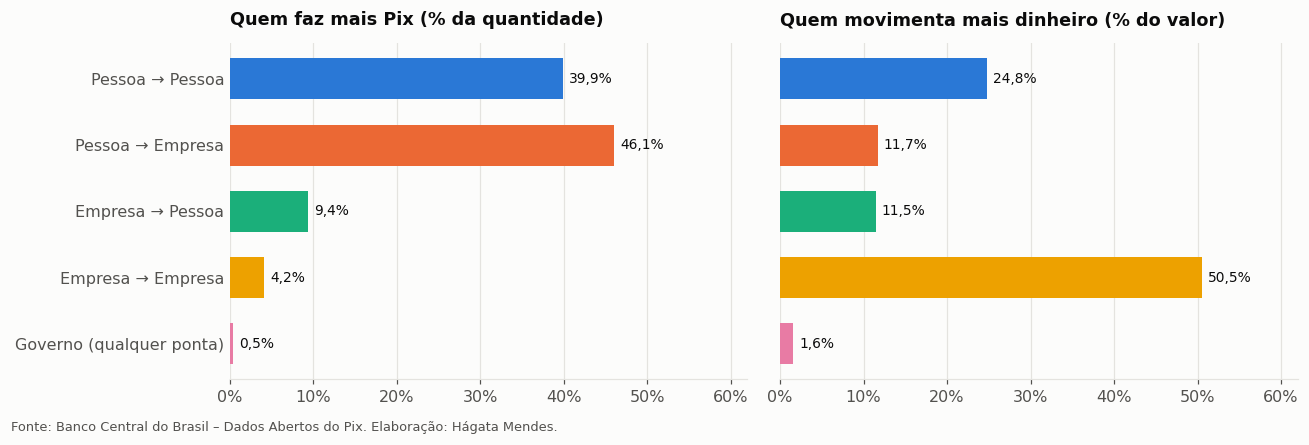

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
ordem = cat.NATUREZA_ORDEM[::-1]
for ax, col, titulo in [(axes[0], "% da quantidade", "Quem faz mais Pix (% da quantidade)"),
                        (axes[1], "% do valor", "Quem movimenta mais dinheiro (% do valor)")]:
    barras = ax.barh(ordem, comp.loc[ordem, col], color=[cores[n] for n in ordem], height=0.62)
    for b in barras:
        ax.annotate(f"{br(b.get_width(), 1)}%", (b.get_width(), b.get_y() + b.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=estilo.TEXTO)
    ax.set_title(titulo, fontsize=11.5)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.set_xlim(0, 62)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.tick_params(axis="y", length=0)
estilo.fonte(fig)
plt.tight_layout(); plt.show()

**Leitura:** as duas metades parecem de países diferentes.
- **Empresa → empresa** é só **4,2%** das transações, mas **51%** de todo o dinheiro. O ticket médio é de **R$ 5.260**.
- **Pessoa → empresa** é **46%** das transações, mas só **12%** do valor, com ticket de **R$ 110**. São as compras do dia a dia.

Um Pix entre empresas vale, em média, **48 vezes** um Pix de pessoa para empresa.

### 2.3 Testando a hipótese: por que o ticket médio subiu?

Se o ticket **geral** sobe, há duas explicações possíveis:
1. **Cada tipo** de Pix ficou mais caro (efeito **preço**); ou
2. os tipos caros (empresa → empresa) **ganharam participação** (efeito **mix**).

Para separar os dois, fazemos um **contrafactual**: calculamos o ticket de hoje **usando a composição (mix) de 2024**. Se o resultado ficar perto do ticket de 2024, a alta veio do mix.

In [7]:
def resumo(ano):
    base = df[(df["AnoMes"] // 100 == ano) & (df["AnoMes"] % 100 <= ultimo % 100)]  # jan até o mesmo mês
    t = base.groupby("natureza")[["QUANTIDADE", "VALOR"]].sum().reindex(cat.NATUREZA_ORDEM)
    return pd.DataFrame({"mix": t["QUANTIDADE"] / t["QUANTIDADE"].sum(), "ticket": t["VALOR"] / t["QUANTIDADE"]})

antes, agora = resumo(2024), resumo(ultimo // 100)
tabela = pd.DataFrame({
    "mix 2024 (%)": antes["mix"] * 100, f"mix {ultimo // 100} (%)": agora["mix"] * 100,
    "ticket 2024 (R$)": antes["ticket"], f"ticket {ultimo // 100} (R$)": agora["ticket"],
})
display(tabela)

ticket_2024 = (antes["mix"] * antes["ticket"]).sum()
ticket_hoje = (agora["mix"] * agora["ticket"]).sum()
contrafactual = (antes["mix"] * agora["ticket"]).sum()   # tickets de hoje, mix de 2024
print(f"Ticket geral 2024:                   R$ {br(ticket_2024, 0)}")
print(f"Ticket geral {ultimo // 100}:                   R$ {br(ticket_hoje, 0)}")
print(f"{ultimo // 100} com o mix de 2024 (contrafactual): R$ {br(contrafactual, 0)}")

,mix 2024 (%),mix 2026 (%),ticket 2024 (R$),ticket 2026 (R$)
natureza,,,,
Pessoa → Pessoa,"49,3","39,9","245,4","268,5"
Pessoa → Empresa,"38,9","46,1","118,3","109,8"
Empresa → Pessoa,"8,5","9,4","586,3","528,9"
Empresa → Empresa,"2,9","4,2","5.643,0","5.259,6"
Governo (qualquer ponta),"0,4","0,5","1.176,8","1.468,2"


Ticket geral 2024:                   R$ 386
Ticket geral 2026:                   R$ 433
2026 com o mix de 2024 (contrafactual): R$ 379


**Leitura: hipótese confirmada, e com um detalhe curioso.**
- O ticket geral subiu de **R$ 386** (jan–ago/2024) para **R$ 433** (jan–ago/2026).
- Mas, se a composição tivesse ficado igual à de 2024, o ticket de 2026 seria **R$ 379**, ou seja, **menor** que em 2024.
- Na tabela, os tickets de pessoa → empresa, empresa → pessoa e empresa → empresa **caíram**. Só pessoa → pessoa subiu um pouco.

👉 **Toda a alta do ticket médio vem do efeito mix:** empresa → empresa, que tem ticket de R$ 5 mil, passou de 2,9% para 4,2% das transações e puxou a média para cima, mesmo com cada tipo de Pix ficando, em média, mais barato.

> 📚 Esse é um fenômeno clássico em análise de dados (parente do **Paradoxo de Simpson**): uma média geral pode subir mesmo quando nenhum grupo sobe. Olhar só o número agregado levaria à conclusão errada de que "os Pix estão ficando mais caros".

## 3. Pergunta 5: como o Pix é feito?

O campo `FORMAINICIACAO` só passou a vir preenchido de forma consistente a partir de **dez/2021** (antes, quase tudo era "Não disponível"). Por isso começamos daí, porque usar os meses anteriores distorceria as participações.

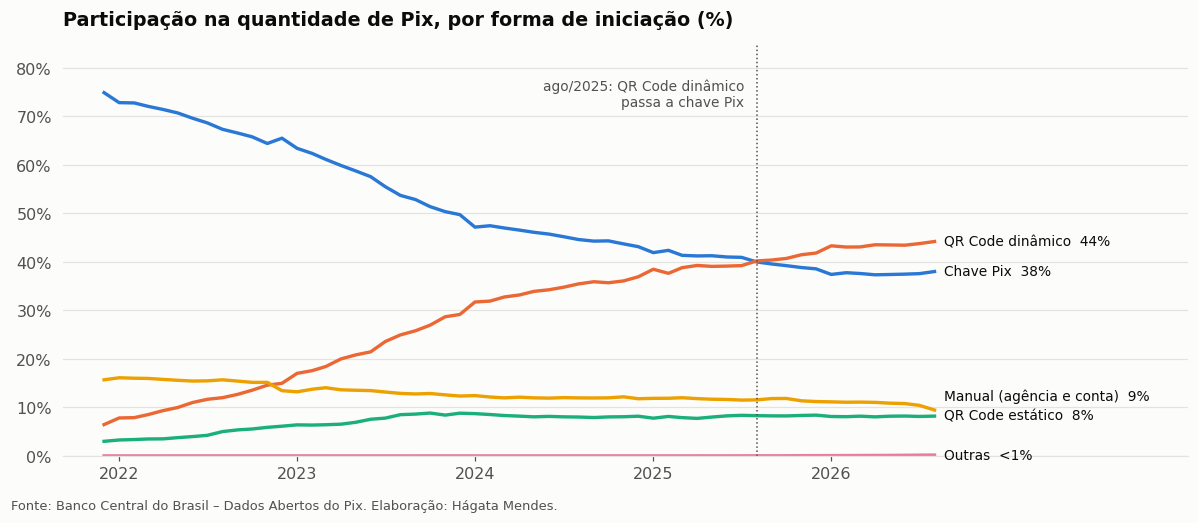

In [8]:
base = df[df["AnoMes"] >= cat.FORMA_INICIO]
qf = base.pivot_table(index="mes", columns="forma", values="QUANTIDADE", aggfunc="sum")[cat.FORMA_ORDEM]
part_forma = qf.div(qf.sum(axis=1), axis=0) * 100
cores_f = dict(zip(cat.FORMA_ORDEM, estilo.CATEGORICAS))

fig, ax = plt.subplots(figsize=(11, 4.6))
for nome in cat.FORMA_ORDEM:
    s = part_forma[nome]
    ax.plot(s.index, s, color=cores_f[nome])
cruz = part_forma.index[part_forma["QR Code dinâmico"] > part_forma["Chave Pix"]].min()
ax.axvline(cruz, color=estilo.TEXTO_2, lw=1, ls=":")
ax.annotate(f"{estilo.mes_abrev(cruz)}/{cruz.year}: QR Code dinâmico\npassa a chave Pix", (cruz, 72),
            xytext=(-8, 0), textcoords="offset points", ha="right", fontsize=9, color=estilo.TEXTO_2)
ax.set_title("Participação na quantidade de Pix, por forma de iniciação (%)")
ax.set_ylim(0, 85)
estilo.rotulos_finais(ax, {f"{n}  {estilo.pct(part_forma[n].iloc[-1])}": part_forma[n] for n in cat.FORMA_ORDEM})
ax.set_xlim(right=part_forma.index[-1] + pd.Timedelta(days=520))
ax.set_xticks([pd.Timestamp(a, 1, 1) for a in range(part_forma.index[0].year + 1, part_forma.index[-1].year + 1)], [str(a) for a in range(part_forma.index[0].year + 1, part_forma.index[-1].year + 1)])
estilo.eixo_br(ax, 0, "%")
estilo.fonte(fig)
plt.tight_layout(); plt.show()

**Leitura:** em dez/2021 a **chave Pix** respondia por **75%** das transações. Hoje responde por **38%**. O **QR Code dinâmico**, aquele gerado na maquininha ou no checkout da loja online com o valor já preenchido, saiu de **6%** para **44%** e **passou a chave em ago/2025**.

Isso conversa diretamente com o gráfico de pessoa → empresa: o QR Code dinâmico é a "cara" do Pix no comércio.

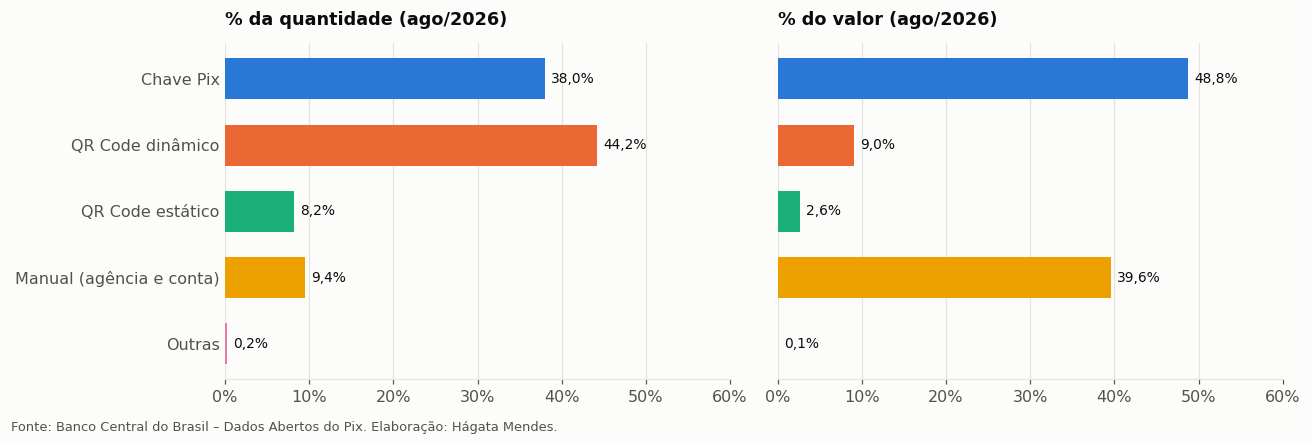

In [9]:
mes_ult = df[df["AnoMes"] == ultimo].groupby("forma")[["QUANTIDADE", "VALOR"]].sum().reindex(cat.FORMA_ORDEM)
comp_f = pd.DataFrame({"% da quantidade": mes_ult["QUANTIDADE"] / mes_ult["QUANTIDADE"].sum() * 100,
                       "% do valor": mes_ult["VALOR"] / mes_ult["VALOR"].sum() * 100})

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
ordem = cat.FORMA_ORDEM[::-1]
for ax, col in zip(axes, comp_f.columns):
    barras = ax.barh(ordem, comp_f.loc[ordem, col], color=[cores_f[n] for n in ordem], height=0.62)
    for b in barras:
        ax.annotate(f"{br(b.get_width(), 1)}%", (b.get_width(), b.get_y() + b.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=estilo.TEXTO)
    ax.set_title(f"{col.capitalize()} ({estilo.mes_abrev(df['mes'].max())}/{ultimo // 100})", fontsize=11.5)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.set_xlim(0, 60); ax.tick_params(axis="y", length=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
estilo.fonte(fig)
plt.tight_layout(); plt.show()

**Leitura:** de novo, quantidade e valor contam histórias diferentes.
- **QR Code** (dinâmico + estático) é **52%** das transações, mas só **12%** do dinheiro: é o **varejo**, com compras pequenas e frequentes.
- **Manual (agência e conta)** é só **9%** das transações, mas **40%** do valor: são as **transferências grandes**, típicas de empresas pagando fornecedores.

## 4. Conclusões

| Pergunta | Resposta |
|---|---|
| **3. Pessoas ou empresas?** | O Pix virou pagamento no comércio: **pessoa → empresa** (47% das transações) passou **pessoa → pessoa** (39%) em **set/2025** |
| **Onde está o dinheiro?** | **Empresa → empresa**: 4,2% das transações, mas **51% do valor** (ticket de R$ 5.260) |
| **Por que o ticket subiu?** | **Efeito mix**: os Pix entre empresas ganharam participação (veja o contrafactual) |
| **5. Chave ou QR Code?** | O **QR Code dinâmico** (44%) passou a **chave Pix** (38%) em **ago/2025** |

**Lições de análise deste notebook:** (1) quantidade e valor podem contar histórias opostas, então olhe sempre os dois; (2) uma média geral pode subir mesmo sem nenhum grupo subir (**efeito mix**); (3) verifique quando cada campo começou a ser preenchido antes de usá-lo.

**Próximo notebook:** pergunta 4, **regiões e municípios**.